In [1]:
import torch
import torch.nn as nn

# from src.models.cnn import PlantDiseaseCNN

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

from src.models.cnn import PlantDiseaseCNN

Project root: c:\Users\ASUS\Desktop\Neural Networks Models\plant-disease-cnn


In [3]:
NUM_CLASSES = 38

model = PlantDiseaseCNN(
    num_classes=NUM_CLASSES
)

print(model)

PlantDiseaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Device:", device)

Device: cuda


In [5]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 427,174
Trainable parameters: 427,174


In [6]:
dummy_input = torch.randn(
    2,
    3,
    224,
    224
).to(device)

output = model(dummy_input)

print("Input shape :", dummy_input.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 38])


In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [8]:
import torch
import torch.nn as nn

from torch.optim import AdamW

from src.models.cnn import PlantDiseaseCNN
from src.training.train import train_one_epoch, validate

In [9]:
from datasets import load_dataset

dataset = load_dataset(
    "geraldmc/plantvillage-full",
    revision="v0.1.0"
)

data = dataset["train"]

print("Total images:", len(data))

Total images: 54304


In [10]:
train_full = data.filter(
    lambda x: x["split"] == "train"
)

test_dataset = data.filter(
    lambda x: x["split"] == "test"
)

print("Official train:", len(train_full))
print("Official test:", len(test_dataset))

Official train: 43356
Official test: 10948


In [11]:
from sklearn.model_selection import GroupShuffleSplit

train_df = train_full.to_pandas()
test_df = test_dataset.to_pandas()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.10,
    random_state=42
)

train_indices, val_indices = next(
    splitter.split(
        train_df,
        groups=train_df["leaf_id"]
    )
)

train_df_split = train_df.iloc[
    train_indices
].reset_index(drop=True)

val_df_split = train_df.iloc[
    val_indices
].reset_index(drop=True)

In [12]:
from datasets import Dataset, Image as HFImage

train_dataset = Dataset.from_pandas(
    train_df_split,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df_split,
    preserve_index=False
)

train_dataset = train_dataset.cast_column(
    "image",
    HFImage()
)

val_dataset = val_dataset.cast_column(
    "image",
    HFImage()
)

test_dataset = test_dataset.cast_column(
    "image",
    HFImage()
)

In [13]:
from src.data.preprocessing import (
    get_train_transform,
    get_eval_transform
)

In [14]:
train_transform = get_train_transform()
eval_transform = get_eval_transform()

In [15]:
from src.data.dataset import PlantDiseaseDataset

train_ds = PlantDiseaseDataset(
    train_dataset,
    transform=train_transform
)

val_ds = PlantDiseaseDataset(
    val_dataset,
    transform=eval_transform
)

test_ds = PlantDiseaseDataset(
    test_dataset,
    transform=eval_transform
)

In [16]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [17]:
NUM_CLASSES = 38

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = PlantDiseaseCNN(
    num_classes=NUM_CLASSES
).to(device)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [18]:
criterion = nn.CrossEntropyLoss()

In [19]:
optimizer = AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [20]:
train_loss, train_acc = train_one_epoch(
    model=model,
    loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device
)

val_loss, val_acc = validate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device
)

print(
    f"Train Loss: {train_loss:.4f}"
)

print(
    f"Train Accuracy: {train_acc * 100:.2f}%"
)

print(
    f"Validation Loss: {val_loss:.4f}"
)

print(
    f"Validation Accuracy: {val_acc * 100:.2f}%"
)

Train Loss: 1.7443
Train Accuracy: 50.39%
Validation Loss: 1.0159
Validation Accuracy: 69.11%


In [21]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\ASUS\Desktop\Neural Networks Models\plant-disease-cnn


In [22]:
import torch

HISTORY_PATH = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "baseline_training_history.pt"
)

history = torch.load(
    HISTORY_PATH,
    weights_only=False
)

print("Training history loaded successfully.")
print("Keys:", history.keys())

Training history loaded successfully.
Keys: dict_keys(['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'learning_rate'])


In [23]:
from src.utils.visualization import plot_training_history

plot_paths = plot_training_history(
    history,
    save_dir=str(
        PROJECT_ROOT / "results" / "plots"
    )
)


TRAINING PLOTS SAVED

Loss plot:       c:\Users\ASUS\Desktop\Neural Networks Models\plant-disease-cnn\results\plots\training_loss.png
Accuracy plot:   c:\Users\ASUS\Desktop\Neural Networks Models\plant-disease-cnn\results\plots\training_accuracy.png
Learning-rate:   c:\Users\ASUS\Desktop\Neural Networks Models\plant-disease-cnn\results\plots\learning_rate.png


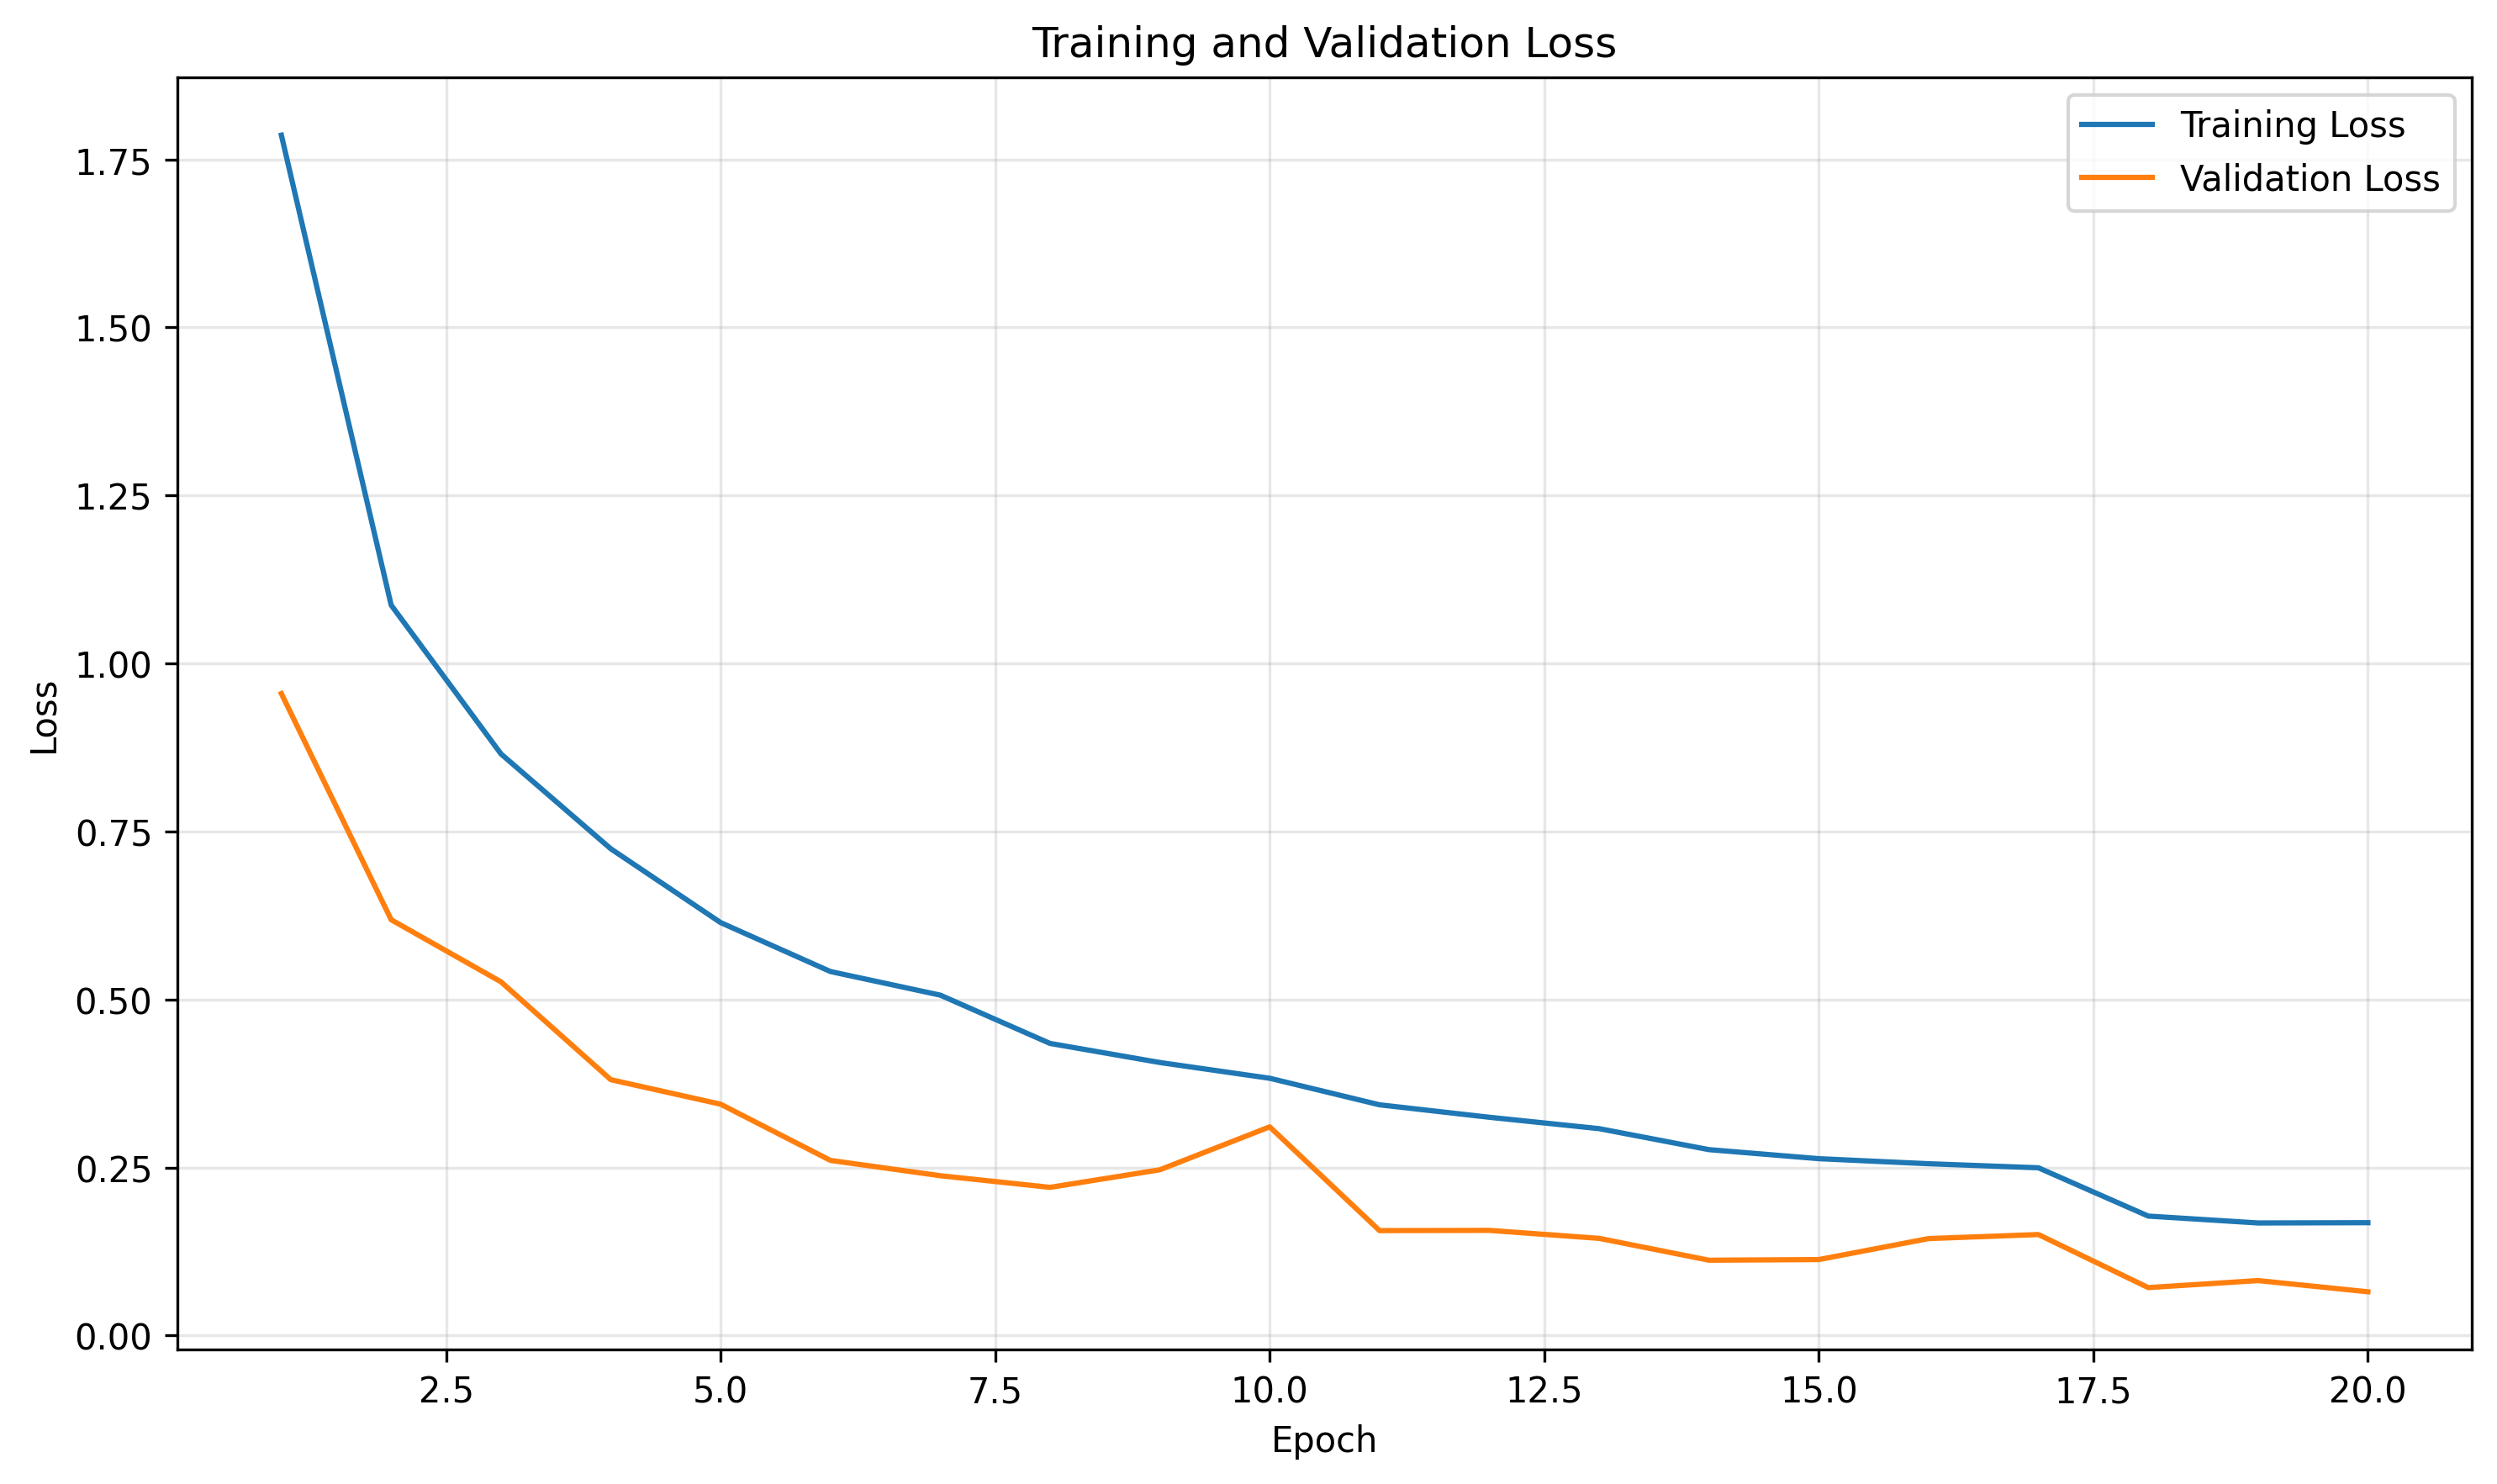

In [24]:
from IPython.display import Image, display

display(
    Image(
        filename=plot_paths["loss"]
    )
)

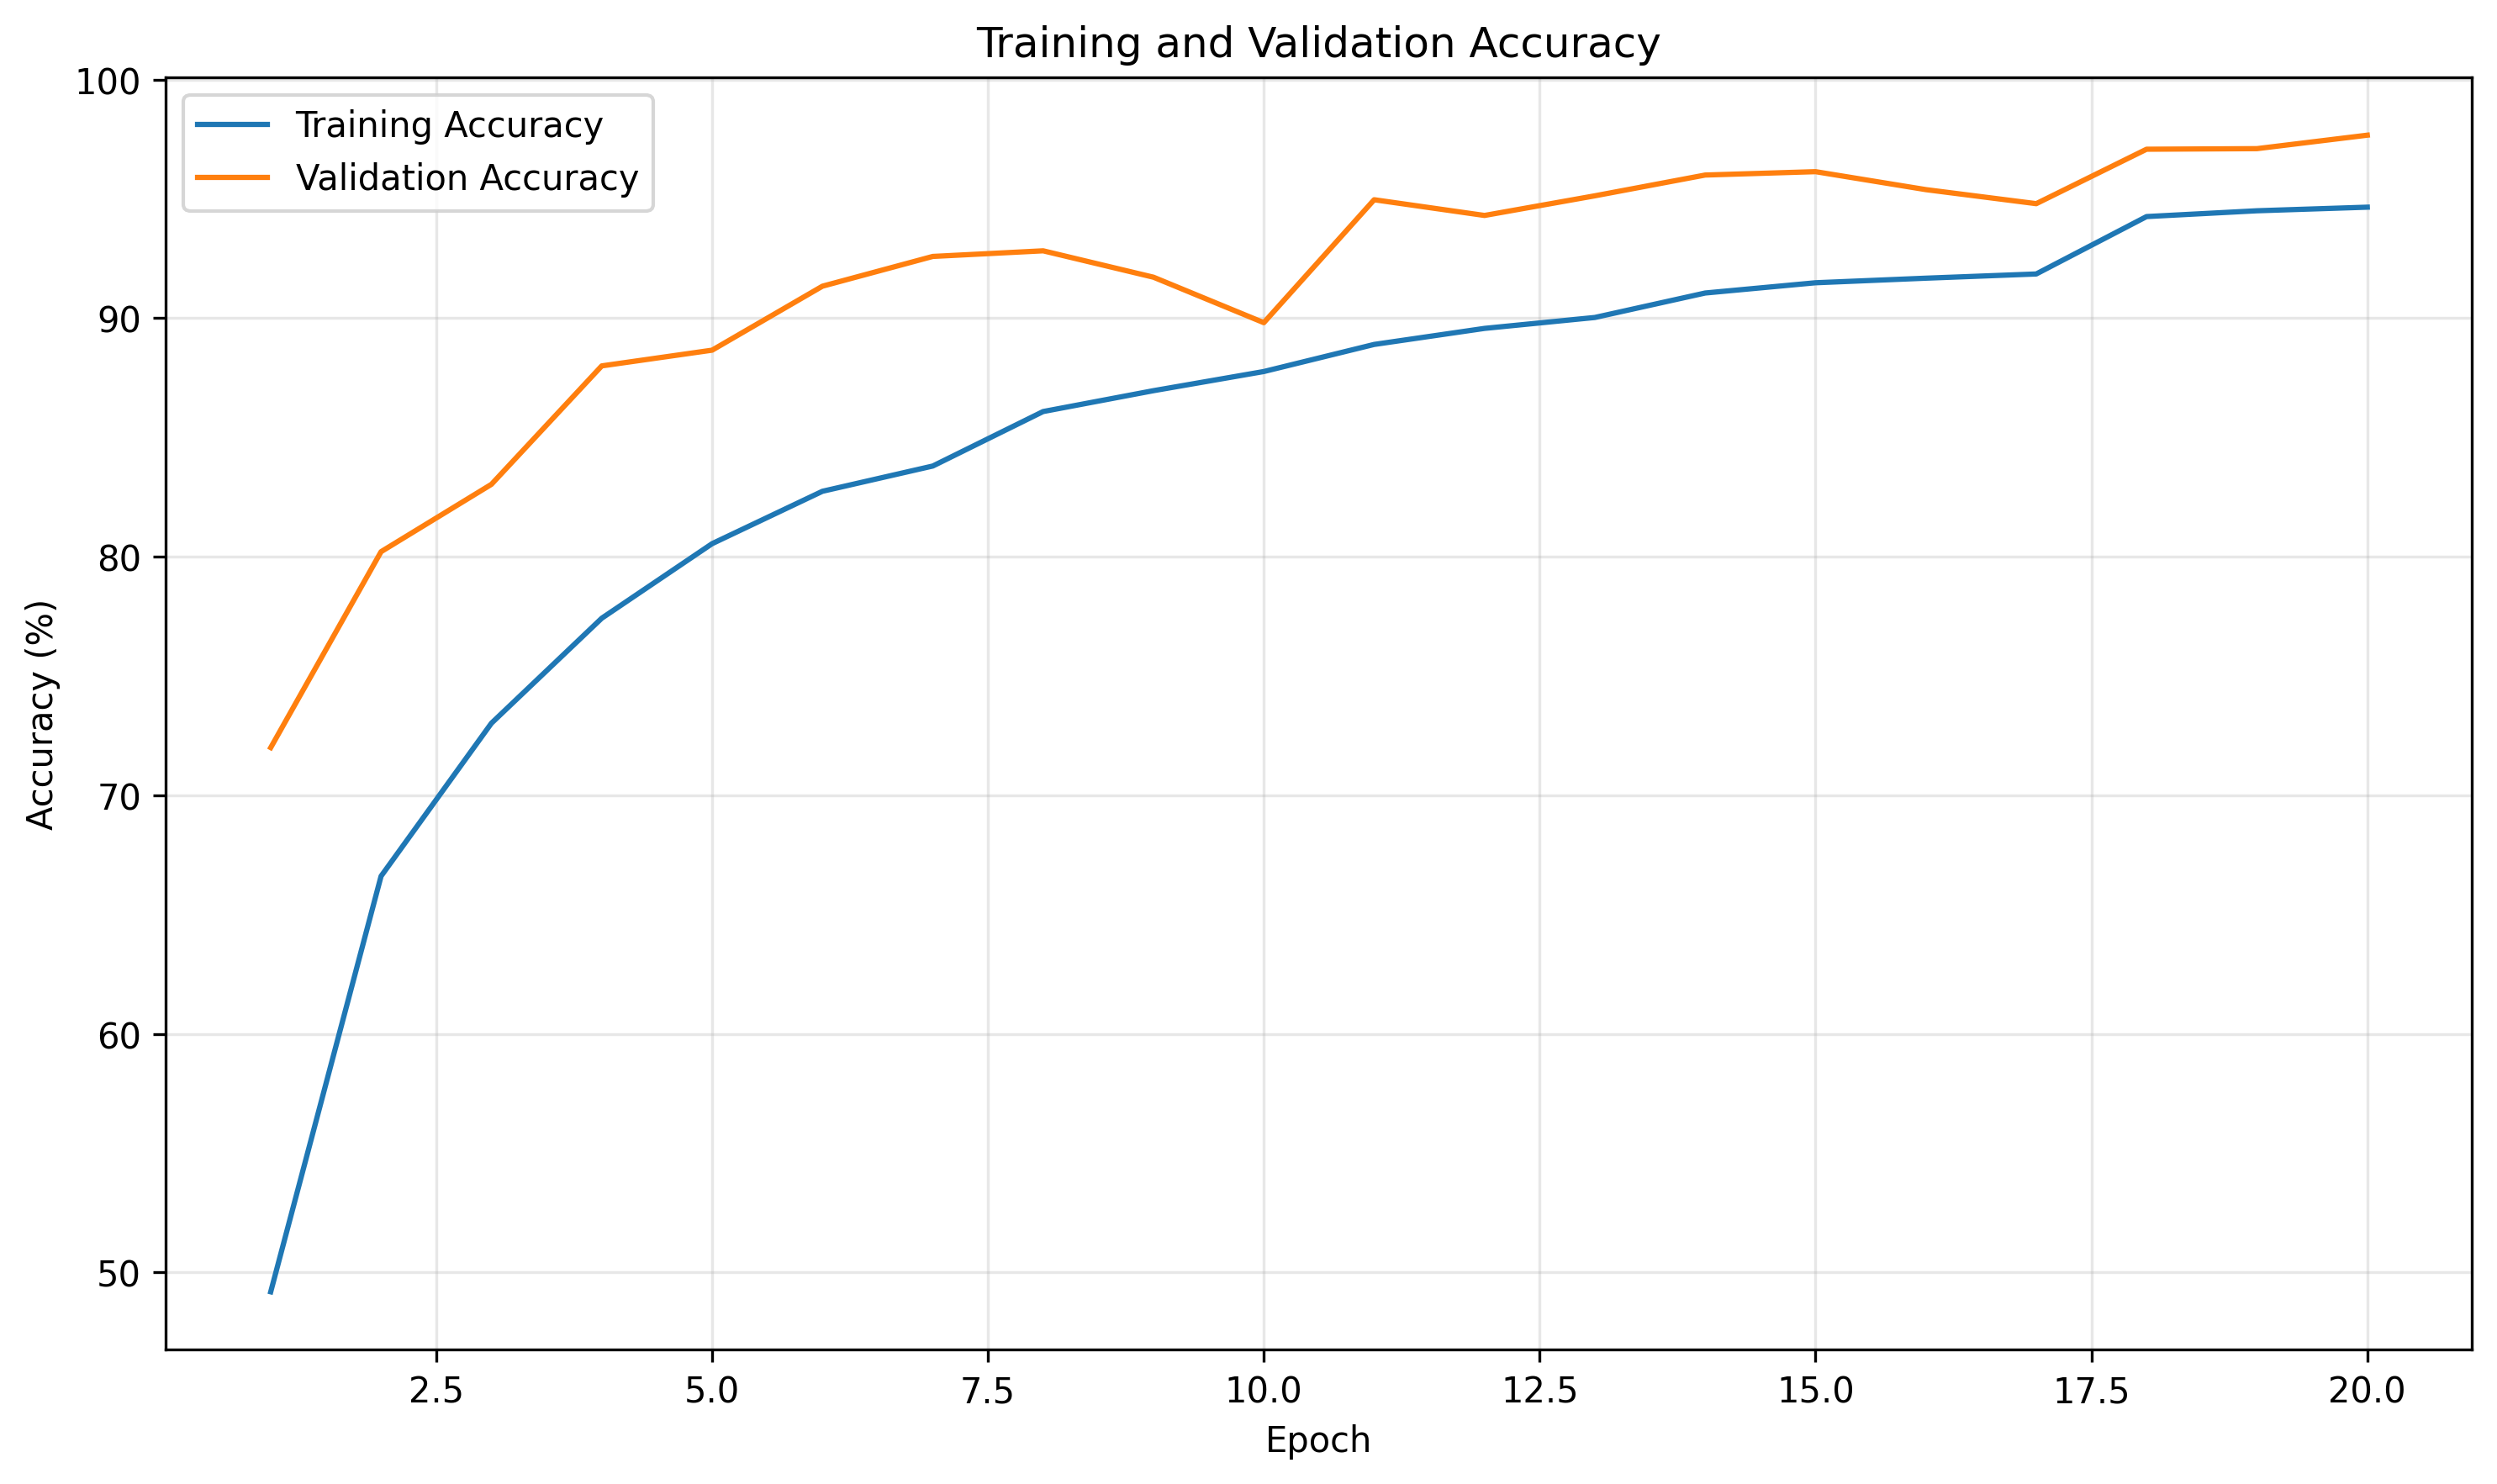

In [25]:
display(
    Image(
        filename=plot_paths["accuracy"]
    )
)

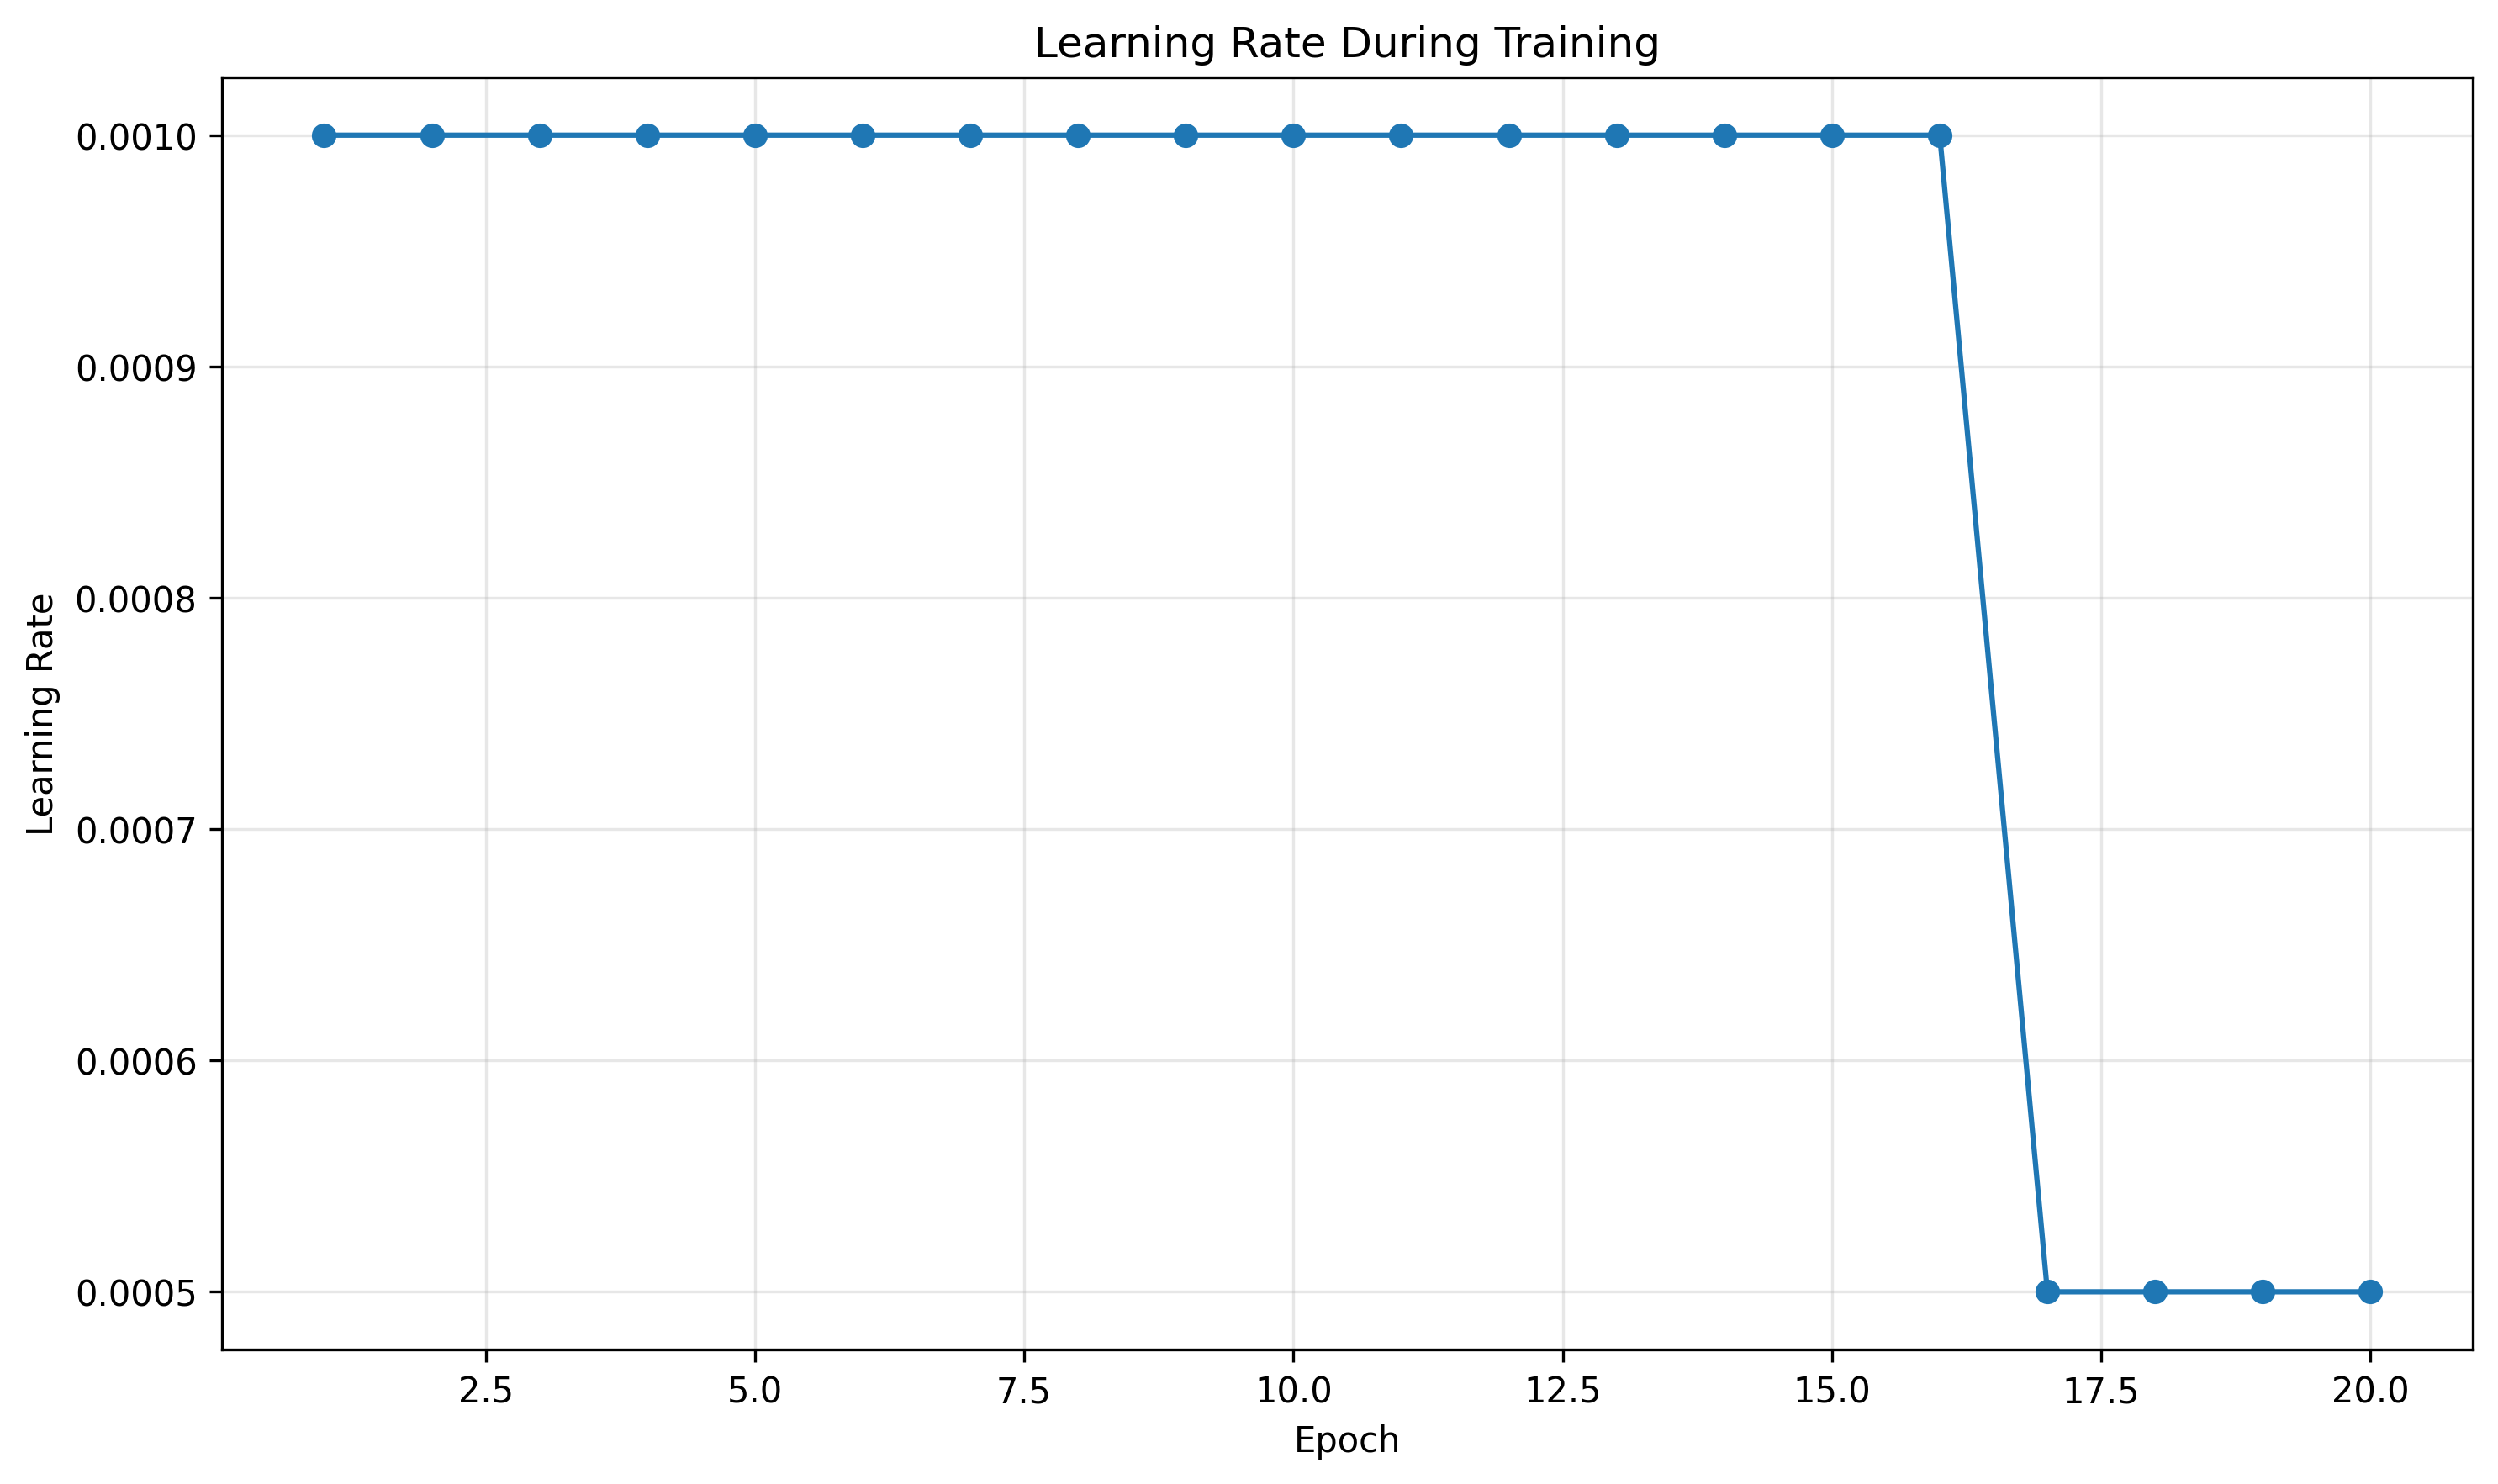

In [26]:
display(
    Image(
        filename=plot_paths["learning_rate"]
    )
)

In [27]:
import pandas as pd

history_df = pd.DataFrame({
    "Epoch": range(
        1,
        len(history["train_loss"]) + 1
    ),
    "Train Loss": history["train_loss"],
    "Validation Loss": history["val_loss"],
    "Train Accuracy": [
        x * 100
        for x in history["train_accuracy"]
    ],
    "Validation Accuracy": [
        x * 100
        for x in history["val_accuracy"]
    ],
    "Learning Rate": history["learning_rate"]
})

history_df

,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy,Learning Rate
0,1,1.785967,0.955097,49.189383,72.000000,0.0010
1,2,1.086703,0.618601,66.611262,80.211765,0.0010
2,3,0.865332,0.526173,73.022043,83.035294,0.0010
3,4,0.724147,0.380604,77.422902,88.000000,0.0010
4,5,0.614364,0.344144,80.547742,88.658824,0.0010
5,6,0.541556,0.260517,82.744336,91.341176,0.0010
6,7,0.506435,0.237745,83.802997,92.588235,0.0010
7,8,0.434558,0.220418,86.086534,92.823529,0.0010
8,9,0.406168,0.246577,86.961080,91.717647,0.0010
9,10,0.382753,0.310456,87.764026,89.811765,0.0010


In [28]:
best_epoch = (
    history_df.loc[
        history_df["Validation Loss"].idxmin()
    ]
)

print("Best Epoch:")
print(best_epoch)

Best Epoch:
Epoch                  20.000000
Train Loss              0.167845
Validation Loss         0.065040
Train Accuracy         94.652994
Validation Accuracy    97.670588
Learning Rate           0.000500
Name: 19, dtype: float64


In [29]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent

CONFUSION_MATRIX_PATH = (
    PROJECT_ROOT
    / "results"
    / "confusion_matrix"
    / "baseline_confusion_matrix.csv"
)

cm_df = pd.read_csv(
    CONFUSION_MATRIX_PATH,
    index_col=0
)

print("Confusion matrix loaded successfully.")
print("Shape:", cm_df.shape)

Confusion matrix loaded successfully.
Shape: (38, 38)


In [ ]:
cm = cm_df.values

class_names = cm_df.index.tolist()

# Remove correct predictions from the diagonal
error_matrix = cm.copy()

np.fill_diagonal(
    error_matrix,
    0
)

# Get all non-zero misclassification pairs
errors = []

for true_idx in range(len(class_names)):
    for pred_idx in range(len(class_names)):

        count = error_matrix[
            true_idx,
            pred_idx
        ]

        if count > 0:

            errors.append({
                "True Class": class_names[true_idx],
                "Predicted Class": class_names[pred_idx],
                "Misclassified Images": int(count)
            })

errors_df = pd.DataFrame(errors)

errors_df = errors_df.sort_values(
    "Misclassified Images",
    ascending=False
).reset_index(drop=True)

errors_df.head(20)s

,True Class,Predicted Class,Misclassified Images
0,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight,20
1,Tomato___Early_blight,Tomato___Target_Spot,17
2,Tomato___Late_blight,Potato___Late_blight,12
3,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,9
4,Tomato___Bacterial_spot,Tomato___Tomato_Yellow_Leaf_Curl_Virus,7
5,Tomato___Target_Spot,Tomato___healthy,7
6,Tomato___Early_blight,Tomato___Late_blight,6
7,Soybean___healthy,Apple___healthy,6
8,Potato___healthy,Soybean___healthy,6
9,Potato___Late_blight,Tomato___Late_blight,6


In [31]:
class_analysis = []

for i, class_name in enumerate(class_names):

    total = cm[i].sum()

    correct = cm[i, i]

    errors = total - correct

    recall = (
        correct / total
        if total > 0
        else 0
    )

    class_analysis.append({
        "Class": class_name,
        "Total Samples": int(total),
        "Correct": int(correct),
        "Errors": int(errors),
        "Recall": recall,
        "Recall (%)": recall * 100
    })

class_analysis_df = pd.DataFrame(
    class_analysis
)

class_analysis_df = class_analysis_df.sort_values(
    "Recall"
)

class_analysis_df

,Class,Total Samples,Correct,Errors,Recall,Recall (%)
22,Potato___healthy,32,21,11,0.656250,65.625000
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,103,83,20,0.805825,80.582524
29,Tomato___Early_blight,200,163,37,0.815000,81.500000
30,Tomato___Late_blight,382,354,28,0.926702,92.670157
34,Tomato___Target_Spot,281,266,15,0.946619,94.661922
21,Potato___Late_blight,200,190,10,0.950000,95.000000
28,Tomato___Bacterial_spot,424,404,20,0.952830,95.283019
9,Corn_(maize)___Northern_Leaf_Blight,197,188,9,0.954315,95.431472
32,Tomato___Septoria_leaf_spot,360,346,14,0.961111,96.111111
0,Apple___Apple_scab,123,119,4,0.967480,96.747967


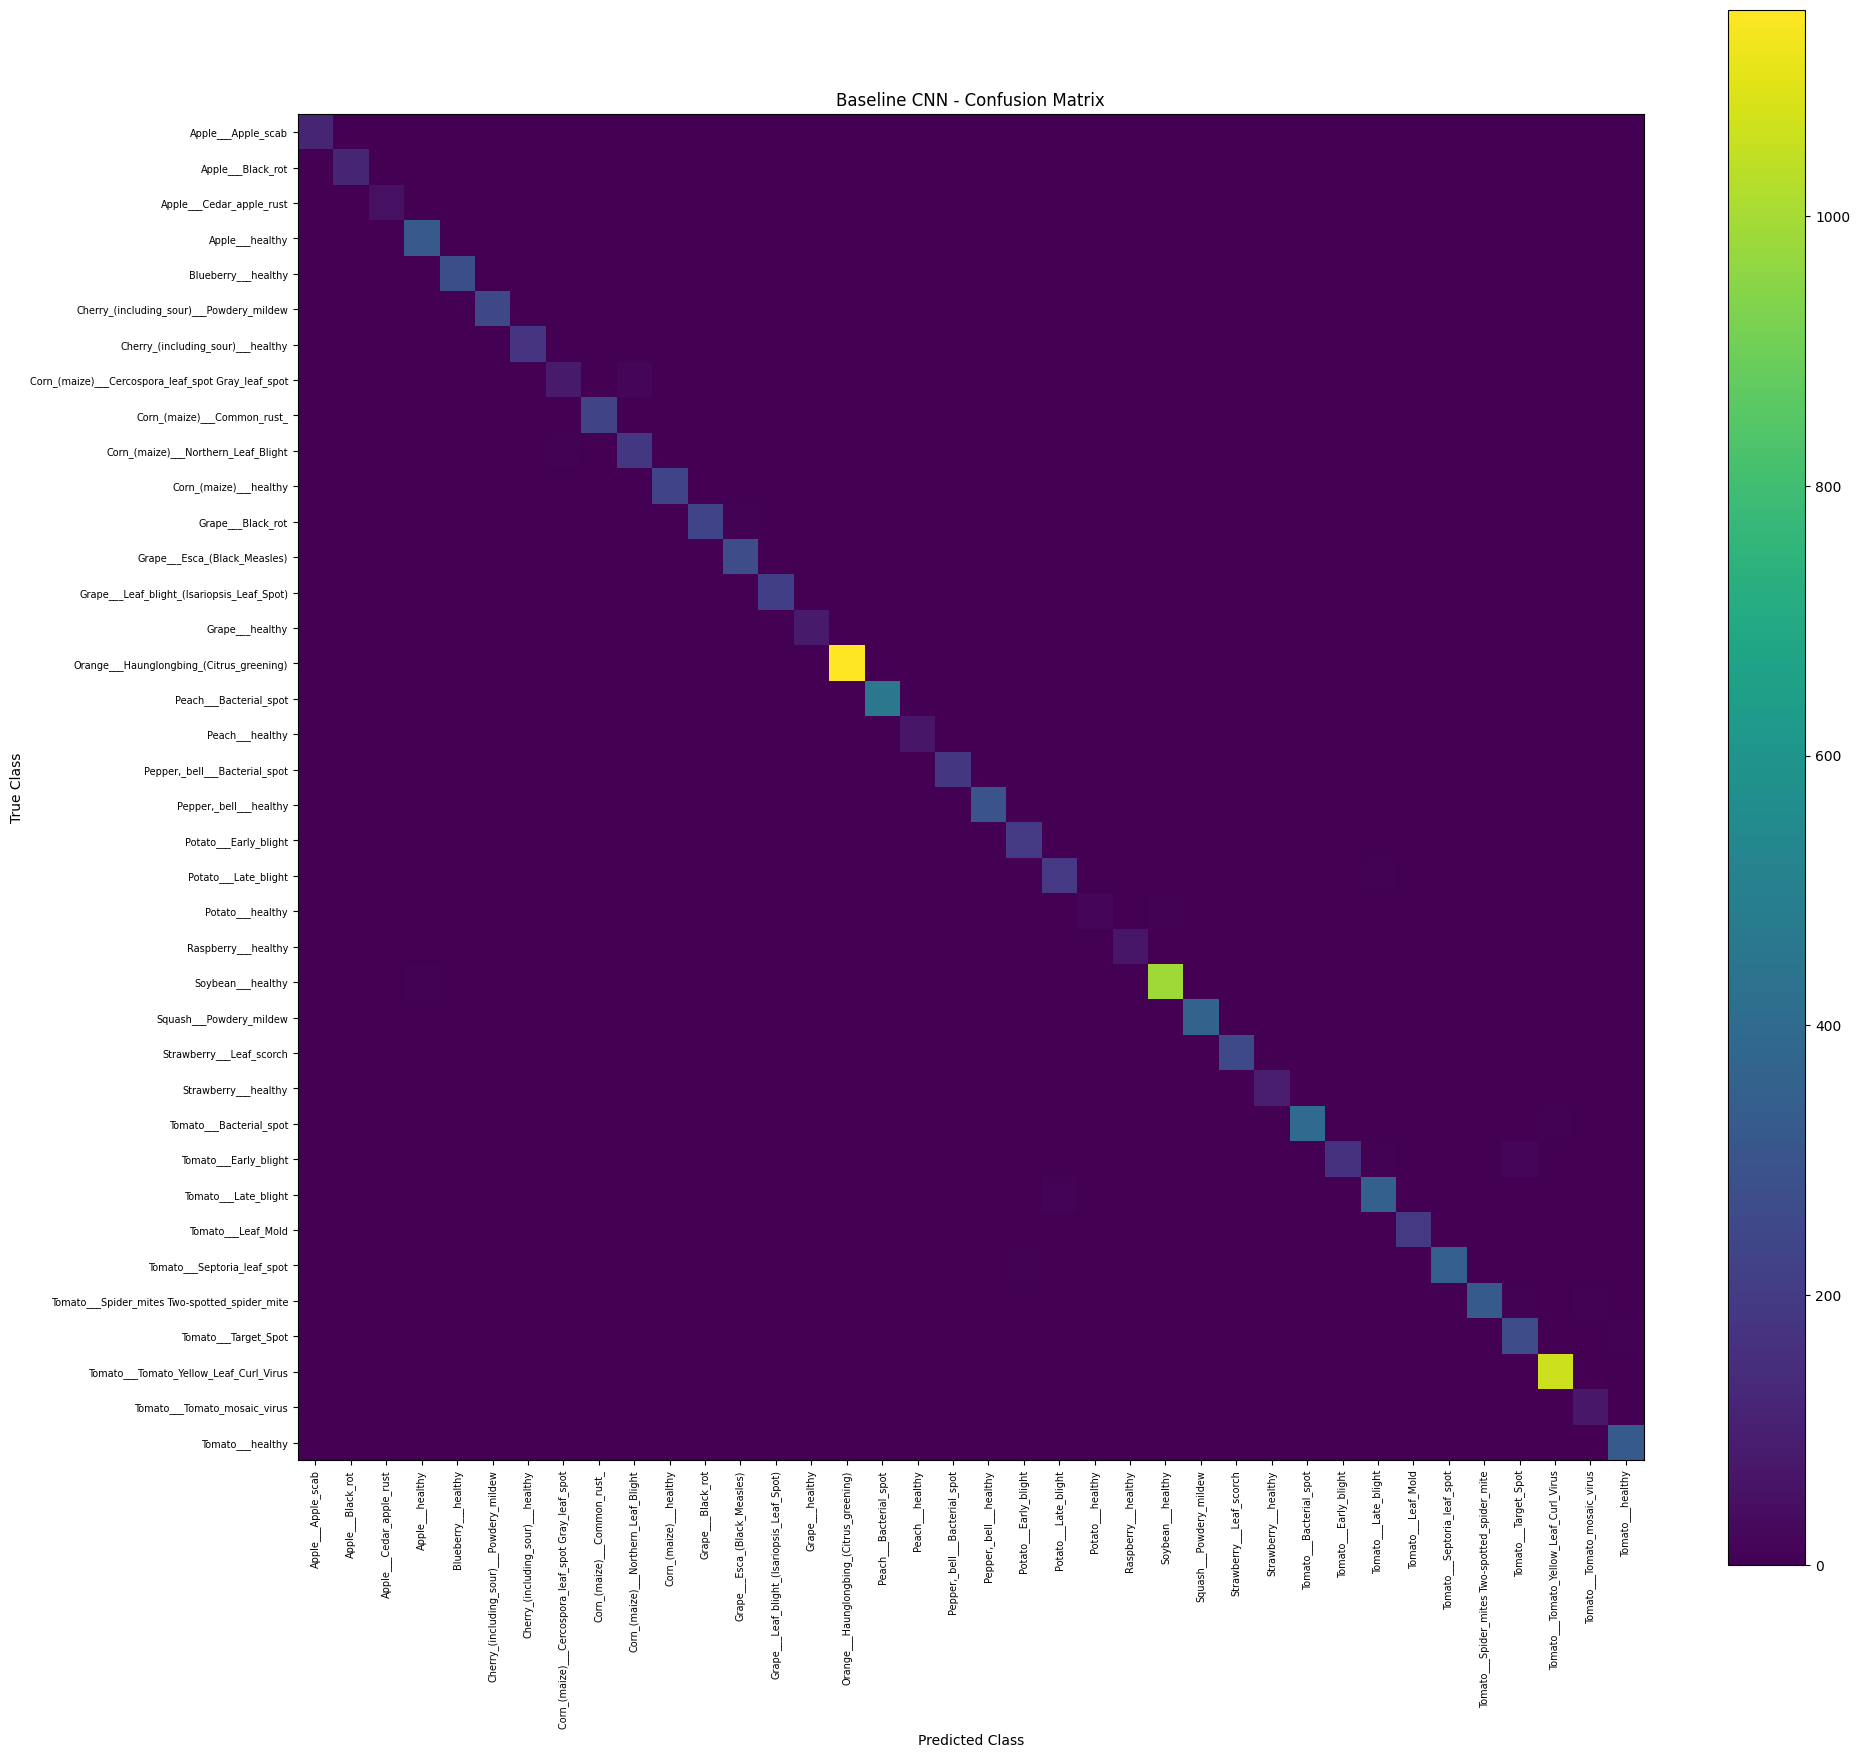

In [32]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(20, 18)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Baseline CNN - Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=90,
    fontsize=7
)

plt.yticks(
    np.arange(len(class_names)),
    class_names,
    fontsize=7
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.tight_layout()

plt.show()

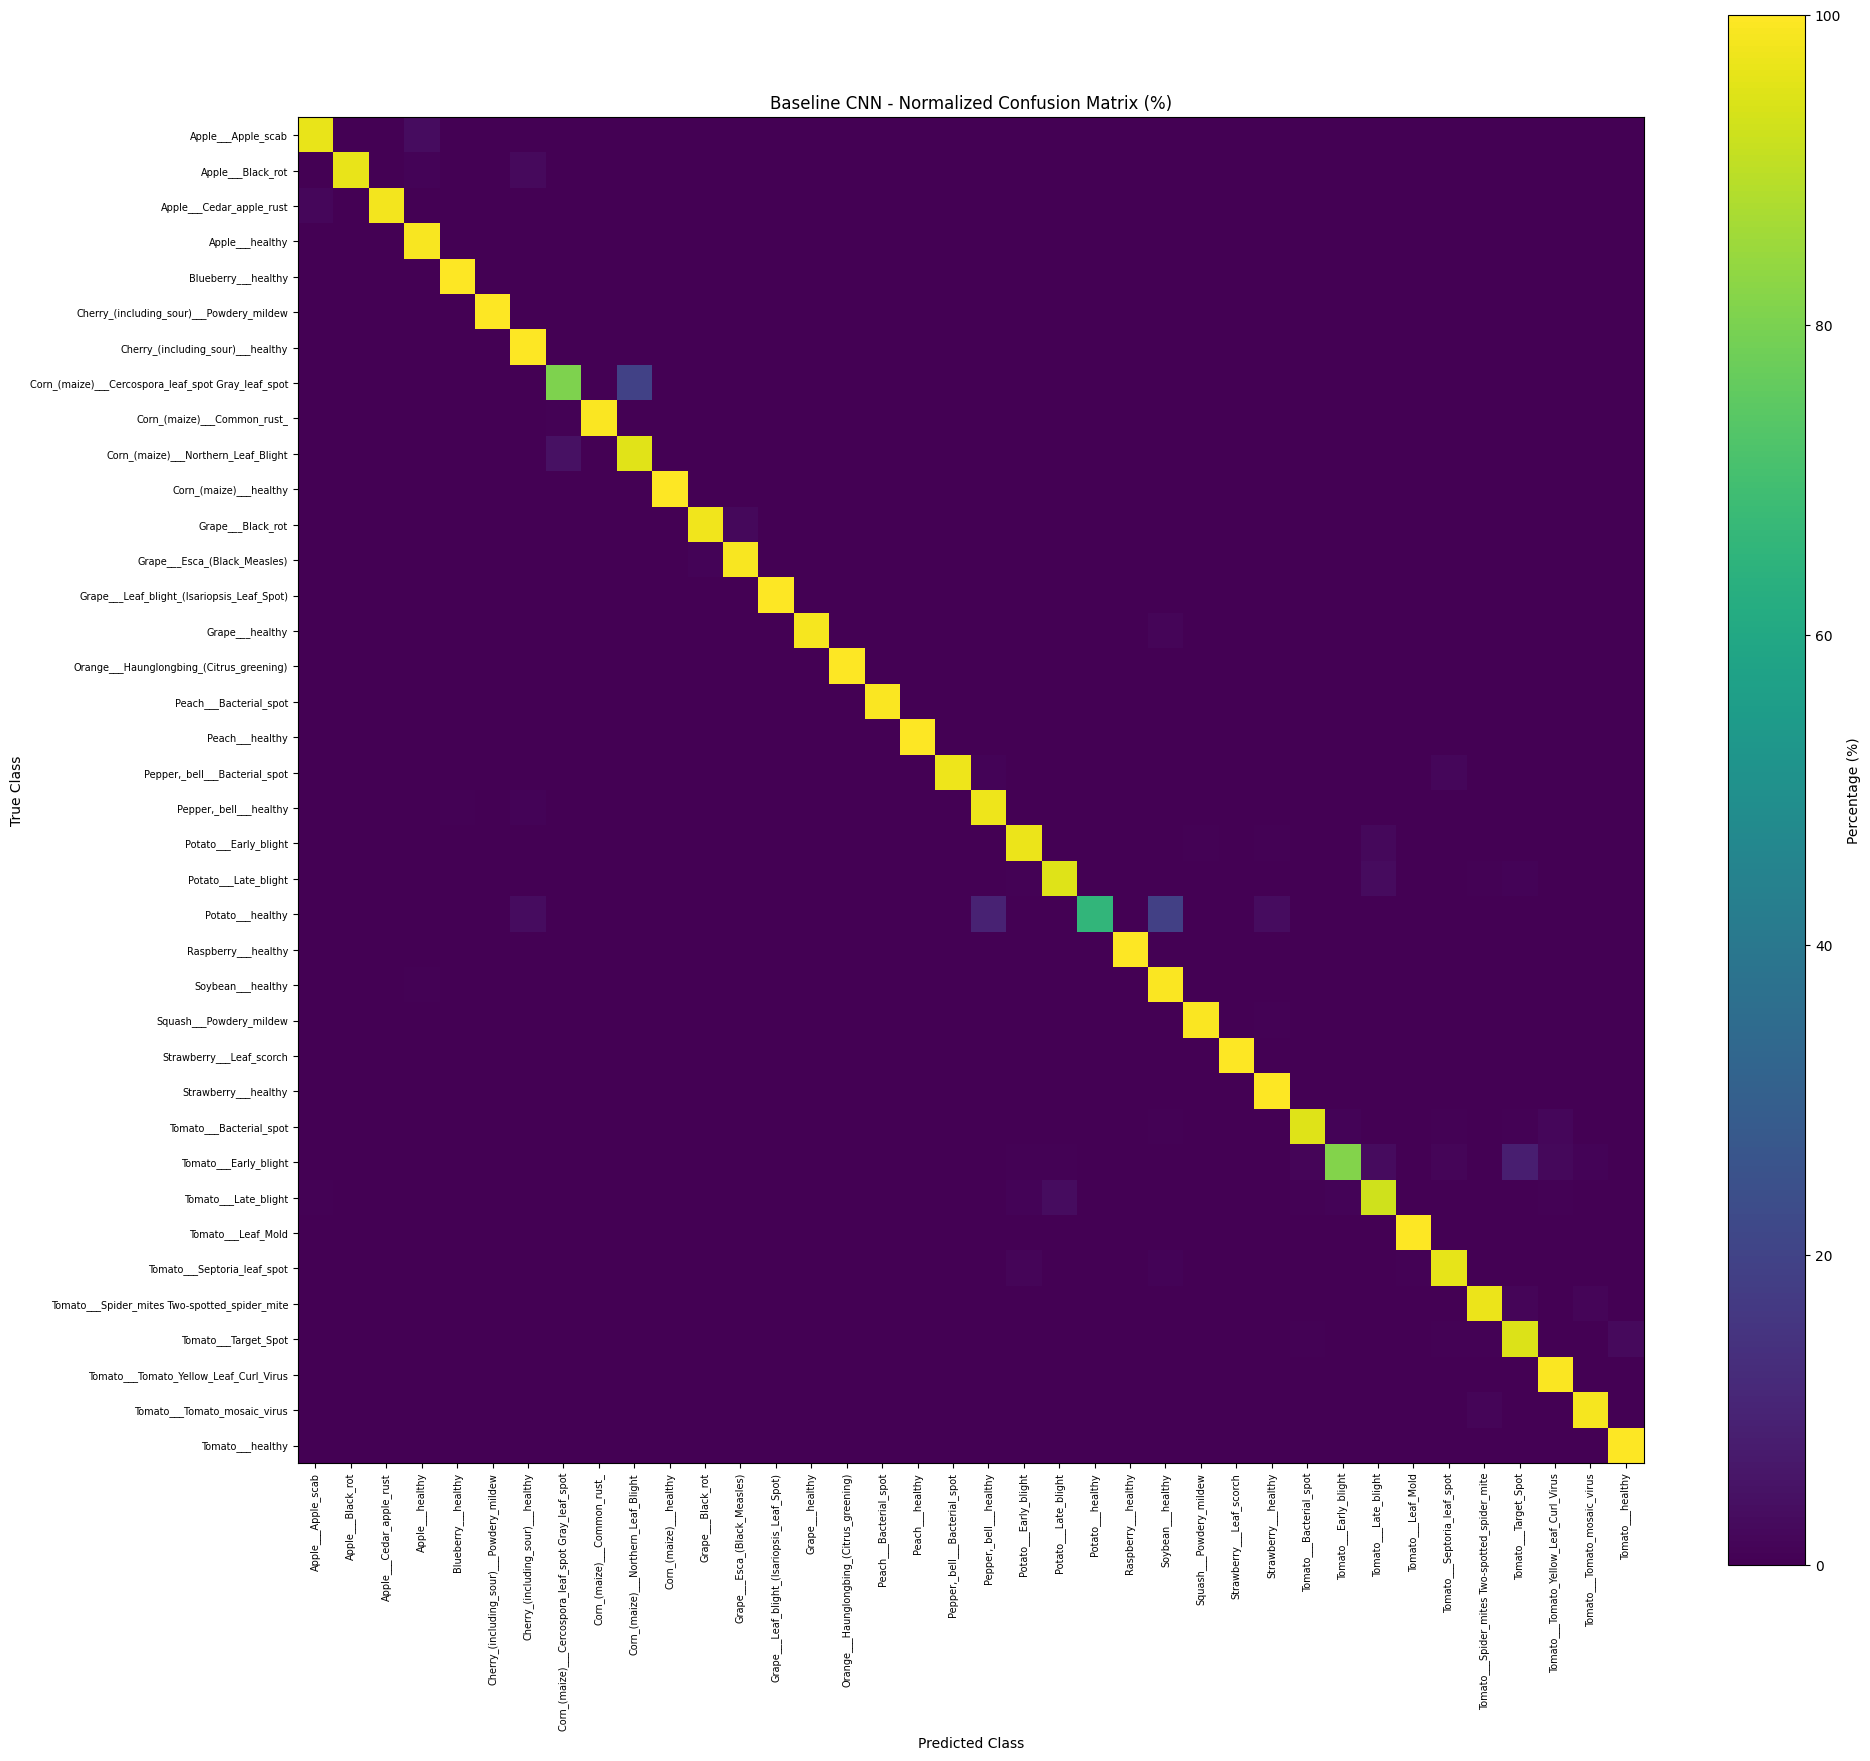

In [33]:
row_totals = cm.sum(
    axis=1,
    keepdims=True
)

cm_percentage = (
    cm / row_totals
) * 100

plt.figure(
    figsize=(20, 18)
)

plt.imshow(
    cm_percentage,
    interpolation="nearest"
)

plt.title(
    "Baseline CNN - Normalized Confusion Matrix (%)"
)

plt.colorbar(
    label="Percentage (%)"
)

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=90,
    fontsize=7
)

plt.yticks(
    np.arange(len(class_names)),
    class_names,
    fontsize=7
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.tight_layout()

plt.show()

In [34]:
target_class = "Potato___healthy"

target_idx = class_names.index(
    target_class
)

row = cm[target_idx]

class_confusion = pd.DataFrame({
    "Predicted Class": class_names,
    "Images": row
})

class_confusion = class_confusion[
    class_confusion["Images"] > 0
]

class_confusion.sort_values(
    "Images",
    ascending=False
)

,Predicted Class,Images
22,Potato___healthy,21
24,Soybean___healthy,6
19,"Pepper,_bell___healthy",3
6,Cherry_(including_sour)___healthy,1
27,Strawberry___healthy,1


In [35]:
def show_class_confusion(
    class_name,
    cm_df
):

    cm = cm_df.values

    class_names = cm_df.index.tolist()

    idx = class_names.index(
        class_name
    )

    row = cm[idx]

    result = pd.DataFrame({
        "Predicted Class": class_names,
        "Images": row
    })

    result = result[
        result["Images"] > 0
    ]

    return result.sort_values(
        "Images",
        ascending=False
    )

In [36]:
show_class_confusion(
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    cm_df
)

,Predicted Class,Images
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,83
9,Corn_(maize)___Northern_Leaf_Blight,20


In [37]:
show_class_confusion(
    "Tomato___Early_blight",
    cm_df
)

,Predicted Class,Images
29,Tomato___Early_blight,163
34,Tomato___Target_Spot,17
30,Tomato___Late_blight,6
35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,4
32,Tomato___Septoria_leaf_spot,3
28,Tomato___Bacterial_spot,3
36,Tomato___Tomato_mosaic_virus,2
20,Potato___Early_blight,1
21,Potato___Late_blight,1


In [38]:
show_class_confusion(
    "Tomato___Target_Spot",
    cm_df
)

,Predicted Class,Images
34,Tomato___Target_Spot,266
37,Tomato___healthy,7
28,Tomato___Bacterial_spot,2
33,Tomato___Spider_mites Two-spotted_spider_mite,2
32,Tomato___Septoria_leaf_spot,2
3,Apple___healthy,1
36,Tomato___Tomato_mosaic_virus,1
